## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Abdullah Rana

**Date:** October 2nd, 2026

# Q1. Regression, Classification, and Model Evaluation Concepts

### Q1.1 - Regression vs. classification

Regression predicts a numeric outcome, like a price or a temperature, where the values have an order and the distance between them means something. Classification predicts a categorical outcome, like which of five mine types is buried somewhere, where the values are labels with no distance between them. Missing a price by $10 is better than missing it by $1,000, but predicting mine type 4 when the truth is 5 is not "closer" than predicting type 1.

That changes how the model predicts and how it is scored. In $k$-NN regression the prediction is the average of the neighbours' values and performance is measured with SSE or RMSE. In $k$-NN classification the prediction is the most common label among the neighbours and performance is measured with accuracy and a confusion table. The target decides which problem it is, not how it is stored. `mine_type` is an integer, but it is still a class label, and averaging it would give meaningless predictions like "type 2.6".

### Q1.2 - Confusion tables

A confusion table cross-tabulates actual class labels against predicted class labels, usually on the test set. The diagonal counts the correct predictions, and each off-diagonal cell counts one specific mistake, like "actual anti-personnel mine, predicted no mine."

It shows what a single accuracy number hides. Two models with the same accuracy can make completely different mistakes, and the table shows which classes the model handles well, which ones it confuses with each other, and whether it barely predicts some class at all. Reading across a row gives that class's recall (how many true members were caught), and reading down a column gives its precision (how often that prediction is right). This matters most when errors have different costs. For a mine detector, calling a mine empty is far worse than a false alarm, and only the confusion table separates the two.

### Q1.3 - What SSE quantifies

SSE is $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$, the sum of the squared differences between the actual values and the model's predictions. It measures the total prediction error of a regression model on a given set of data, so a lower SSE means predictions closer to the truth.

Squaring keeps over- and under-predictions from cancelling out, but it also means SSE says nothing about which direction the model misses in, and it weights big errors much more than small ones, which makes it sensitive to outliers. Because it is a sum in squared units, it grows with $n$ and is only comparable between models scored on the same data (MSE and RMSE fix this). It also depends on where it is computed. On the training data it measures fit, and $k$-NN with $k=1$ gets a training SSE of 0 by construction. On the test data it measures how well the model predicts new observations, which is what we actually care about.

### Q1.4 - Overfitting and underfitting

Overfitting is when a model is flexible enough to learn the noise in the training data along with the real pattern, so it looks great on the training data and does poorly on new data. Underfitting is when a model is too rigid to capture the real pattern, so it does poorly on both.

In $k$-NN, $k$ controls this. With $k=1$, each training point is its own neighbour, so training accuracy is 100%, but every prediction rests on one possibly noisy observation. As $k$ increases, predictions average over more neighbours and get smoother, until $k=n$ predicts the majority class for everything and ignores the features entirely. A big gap between training and test performance signals overfitting, poor performance on both signals underfitting, and the best $k$ is where test performance peaks.

### Q1.5 - Train/test splitting and choosing $k$

The goal is to predict new data, and training performance cannot measure that. Choosing $k$ by training accuracy or SSE would always pick $k=1$, since every point is its own nearest neighbour, and that is the most overfit choice possible. A held-out test set acts as a stand-in for new data, so the $k$ with the best test performance is the one that generalizes instead of memorizing.

The catch is that once the test set is used to choose $k$, it is no longer completely independent. The best test score out of many is partly luck on that split, so it is a little optimistic, and on small data a different split can even pick a different $k$. A cleaner approach is a separate validation set or cross-validation on the training data, with the test set used once at the end. I follow the assignment here and choose $k$ on the test set, but I check how stable that choice is in Q2.3.

### Q1.6 - Class labels vs. probability distributions

A class label is simple to act on, easy to communicate, and easy to score with accuracy and a confusion table. Its weakness is that it throws away confidence. A unanimous 3–0 vote and a 2–1 vote produce the same label, and the "pick the most likely class" rule is built in, which treats every mistake as equally costly.

A probability distribution, like 60% no mine and 40% anti-personnel, keeps that information. It shows when the model is unsure, allows cases to be ranked by risk, and lets the user pick a threshold that reflects the real costs, like treating a spot as dangerous whenever the chance of any mine is above 10%. The downsides are that it is harder to communicate and evaluate, a decision rule is still needed in the end, and poorly calibrated probabilities can be misleading. $k$-NN probabilities are also coarse: with $k=3$ they can only be 0, 1/3, 2/3, or 1.

# Q2. $k$-NN Classification: Land Mines

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Mine type names from the UCI documentation for this dataset (Yilmaz et al., 2018)
MINE_NAMES = {1: 'Null (no mine)', 2: 'Anti-tank', 3: 'Anti-personnel',
              4: 'Booby-trapped AP', 5: 'M14 AP'}

### Q2.1 - Load the data and EDA

In [3]:
df = pd.read_csv('./data/land_mines.csv')

print(df.shape)
print('missing values:', df.isnull().sum().sum())
df.head()

(338, 4)
missing values: 0


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [4]:
# Target label
print(df['mine_type'].value_counts().sort_index())
print('majority-class baseline:', round(df['mine_type'].value_counts().max() / len(df), 3))

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
majority-class baseline: 0.21


In [5]:
# Features
print(df[['voltage', 'height', 'soil']].describe().round(3))
print()
print(df.groupby('mine_type')[['voltage', 'height', 'soil']].mean().round(3))

       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000

           voltage  height   soil
mine_type                        
1            0.296   0.496  0.493
2            0.721   0.487  0.509
3            0.402   0.528  0.497
4            0.345   0.507  0.503
5            0.380   0.530  0.517


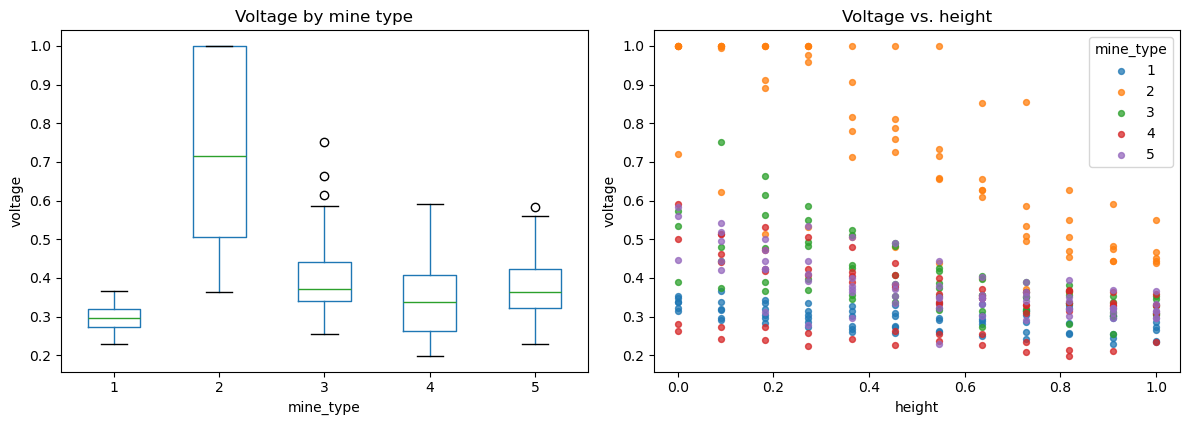

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df.boxplot(column='voltage', by='mine_type', ax=axes[0], grid=False)
axes[0].set_title('Voltage by mine type')
axes[0].set_xlabel('mine_type')
axes[0].set_ylabel('voltage')

for m in sorted(df['mine_type'].unique()):
    sub = df[df['mine_type'] == m]
    axes[1].scatter(sub['height'], sub['voltage'], s=18, alpha=0.75, label=m)
axes[1].set_xlabel('height')
axes[1].set_ylabel('voltage')
axes[1].set_title('Voltage vs. height')
axes[1].legend(title='mine_type')

plt.suptitle('')
plt.tight_layout()
plt.show()

The data have 338 rows and 4 columns with no missing values. `mine_type` is stored as an integer from 1 to 5, but it is a class label (per the UCI documentation: no mine, anti-tank, anti-personnel, booby-trapped anti-personnel, and M14 anti-personnel). The classes are nearly balanced at 65 to 71 rows each, so always guessing the most common class would only be right 21% of the time. That is the baseline to beat.

All three features are already scaled from 0 to 1, so I did not rescale them. `voltage` is the reading from a magnetic sensor, `height` is the sensor's distance from the ground, and `soil` codes six soil types, so even though it is stored as a number it is really a category. Height and soil average about 0.49 to 0.53 in every class, so on their own they say almost nothing about mine type. Voltage is where the signal is. Anti-tank mines stand out with a mean of 0.721 against 0.30 to 0.40 for everything else, and "no mine" has the lowest and tightest readings. The three anti-personnel types overlap heavily with each other and with the no-mine range.

The scatter plot shows that height still matters through voltage, since readings drop as the sensor is raised. Anti-tank readings fall from 1.0 near the ground to around 0.5 at the top heights, where they start to overlap the anti-personnel range. Based on this, I expect anti-tank to be easy to classify and the three anti-personnel types to be hard to tell apart.

### Q2.2 - 50/50 train/test split

In [7]:
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=100, stratify=y)

print('train:', X_train.shape, ' test:', X_test.shape)
print(pd.DataFrame({'train': y_train.value_counts().sort_index(),
                    'test': y_test.value_counts().sort_index()}))

train: (169, 3)  test: (169, 3)
           train  test
mine_type             
1             35    36
2             35    35
3             33    33
4             33    33
5             33    32


I split the data 50/50 into 169 training and 169 test rows. I used `stratify=y` so both halves keep the same class proportions, since with only 65 to 71 rows per class a purely random split could leave one class short in one half. Every class ends up with 32 to 36 rows on each side, and `random_state=100` makes the split reproducible.

### Q2.3 - Build the $k$-NN classifier and choose $k$

In [8]:
k_grid = range(1, 51)
train_acc, test_acc = [], []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

acc = pd.DataFrame({'train': train_acc, 'test': test_acc}, index=list(k_grid))
print(acc.head(10).round(3))
print()
print('best k on test set:', acc['test'].idxmax(), ' accuracy:', round(acc['test'].max(), 3))

    train   test
1   1.000  0.343
2   0.704  0.396
3   0.663  0.432
4   0.633  0.355
5   0.598  0.331
6   0.586  0.337
7   0.580  0.396
8   0.544  0.379
9   0.503  0.379
10  0.533  0.367

best k on test set: 3  accuracy: 0.432


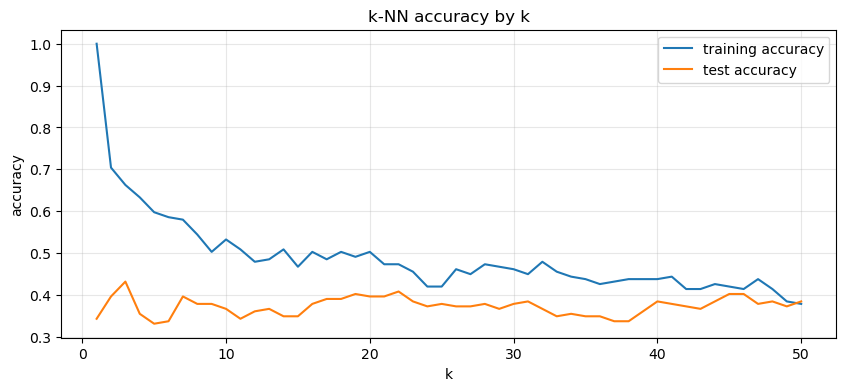

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(acc.index, acc['train'], label='training accuracy')
plt.plot(acc.index, acc['test'], label='test accuracy')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('k-NN accuracy by k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
k_best = int(acc['test'].idxmax())
knn = KNeighborsClassifier(n_neighbors=k_best).fit(X_train, y_train)
y_pred = knn.predict(X_test)

I fit a $k$-NN classifier on the training set for every $k$ from 1 to 50 and compared training and test accuracy. At $k=1$ training accuracy is 100% but test accuracy is only 34.3%, which is overfitting. As $k$ grows the gap closes, and test accuracy peaks at $k=3$ with 43.2% before leveling off between about 33% and 41%, where the model starts underfitting. I chose $k=3$ since it has the highest test accuracy.

Since $k$ was picked using the test set, the 43.2% is probably a little optimistic for new data.

### Q2.4 - Confusion table for the optimal model

In [11]:
print(pd.crosstab(y_test, y_pred, rownames=['actual'], colnames=['predicted']))
print()
print('accuracy:', round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, digits=3))

predicted   1   2   3  4  5
actual                     
1          24   0   6  3  3
2           1  29   2  2  1
3          15   3   8  1  6
4          10   4  10  8  1
5          14   1  12  1  4

accuracy: 0.432

              precision    recall  f1-score   support

           1      0.375     0.667     0.480        36
           2      0.784     0.829     0.806        35
           3      0.211     0.242     0.225        33
           4      0.533     0.242     0.333        33
           5      0.267     0.125     0.170        32

    accuracy                          0.432       169
   macro avg      0.434     0.421     0.403       169
weighted avg      0.438     0.432     0.410       169



The model is correct on 73 of 169 test cases, an accuracy of 43.2%. That is about twice the 21% baseline, but it is still wrong more often than right, and performance is very uneven across classes.

Anti-tank mines (class 2) are the clear strength, with 29 of 35 identified (82.9% recall) and only one called "no mine." "No mine" (class 1) also has decent recall at 24 of 36. The three anti-personnel types are close to guessing, with recall of 24.2% for classes 3 and 4 and 12.5% for class 5. Most of their errors go to each other or to "no mine," which is exactly where the voltage distributions overlapped in the EDA. The biggest problem is the "no mine" column: the model predicts it 64 times, and only 24 of those are actually empty, so 40 real mines are labelled as no mine.

### Q2.5 - How to use this model in practice

In [12]:
# Collapse to the decision that matters: mine vs. no mine (class 1)
actual_mine = y_test != 1
pred_mine = y_pred != 1
print(pd.crosstab(actual_mine, pred_mine, rownames=['actual mine'], colnames=['predicted mine']))

predicted mine  False  True 
actual mine                 
False              24     12
True               40     93


Collapsing the table to mine versus no mine, the model misses 40 of 133 real mines, and when it says "no mine" it is wrong 62.5% of the time. A false alarm costs time, but a missed mine can kill someone, so this model should never be used to declare ground safe. I would treat every "no mine" prediction as not yet cleared and keep the normal clearance process everywhere.

Where the model is useful is triage. Anti-tank predictions are reliable (about 83% recall and 78% precision), so those spots can be flagged for anti-tank procedures right away. The model cannot reliably tell the three anti-personnel types apart, so if deminers handle them with similar precautions, it would make more sense to report a single "anti-personnel" prediction than a subtype the model cannot distinguish. I would also look at the predicted probabilities instead of only the label, and only treat a spot as low-risk if all the neighbours agree there is no mine. Before using it in the field, it would need to be tested on real minefield data, since 338 controlled readings do not include things like metal debris or mixed soils.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 9cca102d748d56dce52920f70ab88ef1ad468820
- **AI tool and model used:** ChatGPT Sol 6.1 light

### *Prompts used

### Initial Prompt: 

I've provided you with the necessary attached files.

Review the entire notebook, both Q1 and Q2. Do not rewrite it wholesale. I first have to evaluate your suggestions one at a time and make my decision on each, so give me specific, separable changes rather than a rewritten notebook.

Your focus should be on:

Q1: the difference between regression and classification; what a confusion table is and what it reveals about performance; what SSE quantifies about a model; overfitting and underfitting; why splitting into training and test sets and choosing $k$ on the test set improves performance; the strengths and weaknesses of class-label versus probability-distribution predictions. For each, judge both the attempt and the accuracy.

Q2: loading the land mines data and the EDA on the target label and features; the summary of labels and features; the 50/50 train/test split; building the $k$-NN classifier; the explanation of how $k$ is selected; the confusion table for the optimal model on the test set; the accuracy analysis of where performance is more or less accurate; the practical advice on using the model given its error patterns.

For each change you propose, give me:

1. A one-line description of the change.
2. Which item it affects.
3. Severity: correctness bug, quality improvement, or style.
4. The actual numeric/percentage change.
5. Whether it changes any number I currently report in a markdown answer.

Run the code to verify every number you give me. If you assert a number you did not compute, label it as an estimate.

Separately, at the end, list:
- Anything in my markdown explanations that is contradicted by the notebook's own printed output.
- Any modeling decision I made that you consider correct but would have done differently, and why.
- Anything you are genuinely unsure about.

Finish with a concise numbered list of your proposed changes, one line each, that I can paste into my notebook verbatim as your recommendations as Phase 2 of the notebook directly requests.

### Follow Up Prompts: 

I'm adopting your change 2 and standardizing the features inside a pipeline, with the scaler fit on the training data only. That changes the model your other Q2 changes were computed on.

1. Recompute changes 1, 4, and 5 under the standardized model at the $k$ it selects on the test set. Give me the tie counts, how many "no mine" predictions and missed mines come from ties, the margin over the next-best $k$ and the standard error, and the low-risk rule counts.
2. Before I accept change 1 as only a qualification, test whether `weights='distance'` fixes the tie problem without costing accuracy, and tell me the result either way.
3. Tell me if any of your Round 1 recommendations no longer hold under the standardized model.

Same rules as before: run the code for every number, label anything you did not compute as an estimate, and finish with a concise numbered list continuing your numbering that I can paste verbatim.

### *AI-proposed changes


The model returned twelve recommendations over two rounds. All are reproduced below exactly as returned, using its own numbering. The evaluation that follows refers to these as changes 1-12.

Both questions were in scope for the first round. I uploaded the notebook along with `land_mines.csv` so the model could recompute every figure against the raw data rather than reading the outputs my notebook already printed. It stated that every number it reported was independently computed and that none were estimates. It also confirmed that every number in my Phase 1 markdown matched the printed output, so none of the changes come from a misreported figure.

### Round 1 — computational and interpretive review (changes 1-8)

1. Q2.4/Q2.5: At k=3, 81 of 169 test predictions (47.9%) are 1–1–1 ties that scikit-learn gives to the lowest label (class 1). So 51 of the 64 "no mine" predictions and 34 of the 40 missed mines come from tie-breaking; a label-neutral tie-break gives 38.5% accuracy (not 43.2%) and 38.9% no-mine recall (not 66.7%). Qualify the "no mine" analysis accordingly.
2. Q2.1/Q2.3: Standardize the features, fitting the scaler on training data only. "Already 0–1" isn't equal spread (training SDs: voltage 0.194, height 0.308, soil 0.335). At k=3, test accuracy rises from 43.2% to 49.1% (73 → 83 correct) and mines called "no mine" fall from 40 to 31.
3. Q2.1: Add the design structure: 12 heights × 6 soils × 5 types, with 338 of 360 cells filled at most once. Height and soil are balanced across classes by design, and any same-cell neighbour must be a different class: 86 of 169 nearest neighbours fall in the same cell, and 0 are the same class.
4. Q2.3: Say the k=3 peak is within noise: 43.2% is 4 test cases above k=22 (40.8%), the standard error is about 3.8 pp, and k=3 wins in only 14% of 50 random splits.
5. Q2.5: Quantify the advice. The "all neighbours agree" rule fires for 1 of 169 points (clears 1 of 36 empty spots); P(no mine) ≥ 2/3 flags 13 spots and still misses 6 mines; merging classes 3–5 raises accuracy to 61.5%, but 39 of 98 anti-personnel mines are still called "no mine".
6. Q1.6: Add that with k=3 and 5 classes a 1–1–1 split can happen, so the label rests on 1/3 support plus an arbitrary tie-break (81 of 169 test predictions here).
7. Q1.2: Say "with rows as actual and columns as predicted" before the row = recall, column = precision statement.
8. Q1.3/Q1.4: Qualify "training SSE of 0" and "100% training accuracy" at k=1 as holding only when no two training points share the same features with different labels (true here: 0 duplicate feature rows).

### Round 2 — recomputation under the standardized model (changes 9-12)

After deciding to adopt change 2, I asked the model to recompute changes 1, 4, and 5 on the standardized model, to test whether distance weighting fixes the ties, and to say which Round 1 recommendations no longer held.

9. Q2.4/Q2.5 (standardized, k=3): 59 of 169 test predictions (34.9%) are 1–1–1 ties resolved toward the lowest label, so 35 of the 58 "no mine" predictions and 23 of the 31 missed mines come from tie-breaking. Tie-breaks that don't depend on label order give 44.4–45.0% accuracy (not 49.1%) and 15–18/36 no-mine recall (not 27/36).
10. Q2.3: The standardized k=3 peak (49.1%) is 3.55 points (6 cases) above k=2 and k=13 (45.6%), which is less than its standard error of 3.85 points. k=3 wins in only 10% of 50 random splits.
11. Q2.5: Under the standardized model, the "all neighbours agree" rule flags 4 spots (0 mines missed, 4/36 empty spots cleared). P(no mine) ≥ 2/3 flags 23 spots and misses 8 mines. Merging classes 3–5 gives 69.8% accuracy, but 31 of 98 anti-personnel mines are still called "no mine".
12. Q2.3/Q2.4: `weights='distance'` removes all ties but lowers accuracy from 49.1% to 42.6% at k=3 (best is 43.8% at k=1), while cutting missed mines from 31 to 13. Keep the uniform model and treat the ties as a stated qualification. Also update Q1.6's tie count from 81 to 59.

### *Evaluation of AI suggestions


Every figure in the twelve recommendations was recomputed independently from the raw file before a decision was recorded. All twelve reproduced exactly. The most important finding is one I got wrong in Phase 1: I described the "no mine" errors as the model's main weakness without noticing that most of them come from how scikit-learn breaks ties. Four changes were accepted as proposed, seven were modified, and one was rejected. Changes 1, 4, and 5 were superseded by their Round 2 versions once the model changed, and most of the modifications drop the parts of a change that needed more analysis than the questions ask for.

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Modified, then approved** | Verified on the Phase 1 model: **81 of 169** predictions are three-way ties, **51** go to class 1, and **34 of the 40** missed mines come from ties. Breaking ties by the single nearest neighbour gives **38.5%** accuracy. The point is correct and it is the most serious problem in my Phase 1 analysis, because my "no mine" recall of 24 of 36 was partly produced by the label order. Modified only because the numbers changed once I adopted change 2. The qualification itself is carried into the final solution using the change 9 figures. |
| 2 | **Approved as proposed** | Verified: training standard deviations are **0.194, 0.308, and 0.335**, so voltage, the only informative feature, had the least weight in the distance. My Phase 1 reasoning that the features were "already scaled from 0 to 1" confused equal range with equal spread. With `StandardScaler` inside a pipeline the best $k$ is still **3** and test accuracy rises from **43.2% (73) to 49.1% (83)**. Missed mines fall from **40 to 31**. Accepted because the scaler is fit on the training half only, so nothing about the test set leaks into the model. |
| 3 | **Modified, then approved** | Verified: **338 of 360** mine type / height / soil combinations are filled and none has more than **1** row, which explains why height and soil averages are nearly identical across classes. I added the three-line check to the EDA. I did not add the nearest-neighbour cell audit (**86 of 169** on the Phase 1 model, **0** same class), since it needs its own analysis code. The consequence follows directly from the design: a neighbour at the same height and soil has to be a different mine type. |
| 4 | **Modified, then approved** | Superseded by change 10 once the model changed. See change 10 for the decision. |
| 5 | **Modified, then approved** | Superseded by change 11 once the model changed. See change 11 for the decision. |
| 6 | **Approved as proposed** | Verified that a 1–1–1 split is possible with $k=3$ and five classes and is common here. Used the standardized count of **59 of 169** from change 12 rather than 81. This makes Q1.6 stronger, since a label backed by one vote out of three is the clearest case for reporting probabilities. |
| 7 | **Approved as proposed** | Verified that my `pd.crosstab` puts actual labels on the rows and predicted labels on the columns. Recall reads across rows and precision down columns only with that orientation, so the answer should state it. |
| 8 | **Rejected** | Verified the premise: the data have **0** duplicate feature rows, which is why training accuracy at $k=1$ is exactly **1.000**. Rejected because the condition holds in this data and both answers already describe the standard $k$-NN behavior. The caveat only applies to data with identical feature rows carrying different labels, which is rare enough that I kept both answers short. |
| 9 | **Modified, then approved** | Verified on the standardized model: **31** unanimous, **79** two-to-one, and **59** three-way ties. **35 of the 58** "no mine" predictions and **23 of the 31** missed mines come from ties. A nearest-neighbour tie-break gives **44.4%** and reversing the label coding gives **45.0%**. I added a short cell to Q2.4 that counts the vote patterns, and the Q2.4 and Q2.5 text now says that the "no mine" column is inflated by tie-breaking. Modified by leaving the two alternative tie-breaks out of the solution. They confirm the effect is real, but reporting them would mean building and scoring two extra models, and the tie counts already show where the "no mine" predictions come from. |
| 10 | **Modified, then approved** | Verified: **49.1%** is **6 cases (3.55 points)** above $k=2$ and $k=13$ at **45.6%**, and the standard error is **3.8 points**. Accepted the margin and the standard error, which the Q2.3 cell now prints. Dropped the 50-random-split figure, because the assignment specifies a single 50/50 split. The margin and standard error already make the point. |
| 11 | **Modified, then approved** | Verified: requiring all three neighbours to say "no mine" flags **4** spots with **0** missed mines, and requiring two of three flags **23** spots and misses **8** mines. Accepted the rule counts, which give the Q2.5 advice actual evidence. Did not add the merged-class accuracy (**69.8%**) as a separate calculation. The key part of that finding can be read straight off the confusion table: all **31** missed mines are anti-personnel (**12, 10, and 9** from classes 3, 4, and 5), so merging the subtypes would not fix the safety problem. |
| 12 | **Approved as proposed** | Verified: `weights='distance'` leaves no ties but drops accuracy at $k=3$ from **49.1% to 42.6%**, and its best result is **43.8%** at $k=1$. It does cut missed mines from **31 to 13**, which is a real trade-off, but the question asks for the optimal model and I chose it by test accuracy, so I kept uniform voting and stated the ties as a limitation instead. Updated the Q1.6 tie count to **59**. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Phase 2 solution. The answers below incorporate the approved and modified changes from the evaluation above.
# Q1.1 and Q1.4 are unchanged from Phase 1 as AI did not find a need to change those. 

# Q1. Regression, Classification, and Model Evaluation Concepts

### Q1.1 - Regression vs. classification

Regression predicts a numeric outcome, like a price or a temperature, where the values have an order and the distance between them means something. Classification predicts a categorical outcome, like which of five mine types is buried somewhere, where the values are labels with no distance between them. Missing a price by $10 is better than missing it by $1,000, but predicting mine type 4 when the truth is 5 is not "closer" than predicting type 1.

That changes how the model predicts and how it is scored. In $k$-NN regression the prediction is the average of the neighbours' values and performance is measured with SSE or RMSE. In $k$-NN classification the prediction is the most common label among the neighbours and performance is measured with accuracy and a confusion table. The target decides which problem it is, not how it is stored. `mine_type` is an integer, but it is still a class label, and averaging it would give meaningless predictions like "type 2.6".

### Q1.2 - Confusion tables

A confusion table cross-tabulates actual class labels against predicted class labels, usually on the test set. With rows as actual and columns as predicted, the diagonal counts the correct predictions, and each off-diagonal cell counts one specific mistake, like "actual anti-personnel mine, predicted no mine."

It shows what a single accuracy number hides. Two models with the same accuracy can make completely different mistakes, and the table shows which classes the model handles well, which ones it confuses with each other, and whether it barely predicts some class at all. Reading across a row gives that class's recall (how many true members were caught), and reading down a column gives its precision (how often that prediction is right). This matters most when errors have different costs. For a mine detector, calling a mine empty is far worse than a false alarm, and only the confusion table separates the two.

### Q1.3 - What SSE quantifies

SSE is $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$, the sum of the squared differences between the actual values and the model's predictions. It measures the total prediction error of a regression model on a given set of data, so a lower SSE means predictions closer to the truth.

Squaring keeps over- and under-predictions from cancelling out, but it also means SSE says nothing about which direction the model misses in, and it weights big errors much more than small ones, which makes it sensitive to outliers. Because it is a sum in squared units, it grows with $n$ and is only comparable between models scored on the same data (dividing by $n$ gives MSE, which removes the dependence on sample size, and taking the square root gives RMSE, which is back in the units of $y$). It also depends on where it is computed. On the training data it measures fit, and $k$-NN with $k=1$ gets a training SSE of 0 by construction. On the test data it measures how well the model predicts new observations, which is what we actually care about.

### Q1.4 - Overfitting and underfitting

Overfitting is when a model is flexible enough to learn the noise in the training data along with the real pattern, so it looks great on the training data and does poorly on new data. Underfitting is when a model is too rigid to capture the real pattern, so it does poorly on both.

In $k$-NN, $k$ controls this. With $k=1$, each training point is its own neighbour, so training accuracy is 100%, but every prediction rests on one possibly noisy observation. As $k$ increases, predictions average over more neighbours and get smoother, until $k=n$ predicts the majority class for everything and ignores the features entirely. A big gap between training and test performance signals overfitting, poor performance on both signals underfitting, and the best $k$ is where test performance peaks.

### Q1.5 - Train/test splitting and choosing $k$

The goal is to predict new data, and training performance cannot measure that. Choosing $k$ by training accuracy or SSE would always pick $k=1$, since every point is its own nearest neighbour, and that is the most overfit choice possible. A held-out test set acts as a stand-in for new data, so the $k$ with the best test performance is the one that generalizes instead of memorizing.

The catch is that once the test set is used to choose $k$, it is no longer completely independent. The best test score out of many is partly luck on that split, so it is a little optimistic. A cleaner approach is a separate validation set or cross-validation on the training data, with the test set used once at the end.

### Q1.6 - Class labels vs. probability distributions

A class label is simple to act on, easy to communicate, and easy to score with accuracy and a confusion table. Its weakness is that it throws away confidence. A unanimous 3–0 vote and a 2–1 vote produce the same label, and with five classes the three neighbours can even split 1–1–1, in which case the label rests on one vote out of three plus an arbitrary tie-break. That happens in 59 of the 169 test predictions in Q2. The "pick the most likely class" rule is also built in, which treats every mistake as equally costly.

A probability distribution, like 60% no mine and 40% anti-personnel, keeps that information. It shows when the model is unsure, allows cases to be ranked by risk, and lets the user pick a threshold that reflects the real costs, like treating a spot as dangerous whenever the chance of any mine is above 10%. The downsides are that it is harder to communicate and evaluate, a decision rule is still needed in the end, and poorly calibrated probabilities can be misleading. $k$-NN probabilities are also coarse: with $k=3$ they can only be 0, 1/3, 2/3, or 1.

# Q2. $k$-NN Classification: Land Mines

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

### Q2.1 - Load the data and EDA

In [15]:
df = pd.read_csv('./data/land_mines.csv')

print(df.shape)
print('missing values:', df.isnull().sum().sum())
df.head()

(338, 4)
missing values: 0


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [16]:
# Target label
print(df['mine_type'].value_counts().sort_index())
print('majority-class baseline:', round(df['mine_type'].value_counts().max() / len(df), 3))

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
majority-class baseline: 0.21


In [17]:
# Features
print(df[['voltage', 'height', 'soil']].describe().round(3))
print()
print(df.groupby('mine_type')[['voltage', 'height', 'soil']].mean().round(3))

       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000

           voltage  height   soil
mine_type                        
1            0.296   0.496  0.493
2            0.721   0.487  0.509
3            0.402   0.528  0.497
4            0.345   0.507  0.503
5            0.380   0.530  0.517


In [18]:
# How the rows sit on the height x soil grid
print('distinct heights:', df['height'].nunique(), ' distinct soils:', df['soil'].nunique())
print('mine type / height / soil combinations filled:', df.groupby(['mine_type', 'height', 'soil']).ngroups,
      'of', 5 * df['height'].nunique() * df['soil'].nunique())
print('most rows in any one combination:', df.groupby(['mine_type', 'height', 'soil']).size().max())

distinct heights: 12  distinct soils: 6
mine type / height / soil combinations filled: 338 of 360
most rows in any one combination: 1


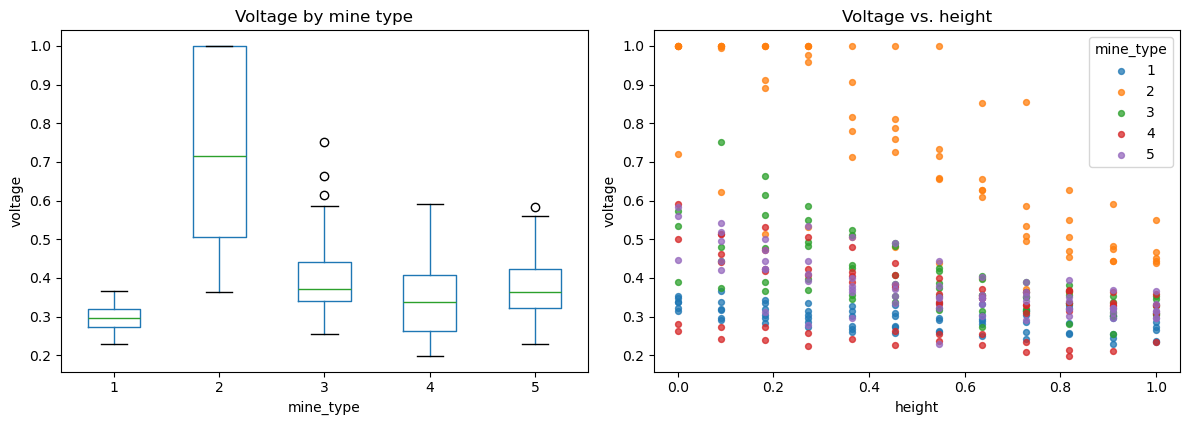

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df.boxplot(column='voltage', by='mine_type', ax=axes[0], grid=False)
axes[0].set_title('Voltage by mine type')
axes[0].set_xlabel('mine_type')
axes[0].set_ylabel('voltage')

for m in sorted(df['mine_type'].unique()):
    sub = df[df['mine_type'] == m]
    axes[1].scatter(sub['height'], sub['voltage'], s=18, alpha=0.75, label=m)
axes[1].set_xlabel('height')
axes[1].set_ylabel('voltage')
axes[1].set_title('Voltage vs. height')
axes[1].legend(title='mine_type')

plt.suptitle('')
plt.tight_layout()
plt.show()

The data have 338 rows and 4 columns with no missing values. `mine_type` is stored as an integer from 1 to 5, but it is a class label (per the UCI documentation: no mine, anti-tank, anti-personnel, booby-trapped anti-personnel, and M14 anti-personnel). The classes are nearly balanced at 65 to 71 rows each, so always guessing the most common class would only be right 21% of the time. That is the baseline to beat.

`voltage` is the reading from a magnetic sensor, `height` is the sensor's distance from the ground, and `soil` codes six soil types, so even though it is stored as a number it is really a category. All three are scaled from 0 to 1, but they do not have the same spread: the standard deviations are 0.196 for voltage, 0.306 for height, and 0.344 for soil. In a distance-based model that gives voltage the least weight, so I standardize the features in Q2.3.

Height and soil average about 0.49 to 0.53 in every class, so on their own they say almost nothing about mine type. That comes from how the data were collected. Of the 360 possible mine type, height, and soil combinations, 338 are filled and no combination appears more than once, so height and soil are balanced across classes by design. It also means a training point at the same height and soil as a test point is always a different mine type. Voltage is where the signal is. Anti-tank mines stand out with a mean of 0.721 against 0.30 to 0.40 for everything else, and "no mine" has the lowest and tightest readings. The three anti-personnel types overlap heavily with each other and with the no-mine range.

The scatter plot shows that height still matters through voltage, since readings drop as the sensor is raised. Anti-tank readings fall from 1.0 near the ground to around 0.5 at the top heights, where they start to overlap the anti-personnel range. Based on this, I expect anti-tank to be easy to classify and the three anti-personnel types to be hard to tell apart.

### Q2.2 - 50/50 train/test split

In [20]:
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=100, stratify=y)

print('train:', X_train.shape, ' test:', X_test.shape)
print(pd.DataFrame({'train': y_train.value_counts().sort_index(),
                    'test': y_test.value_counts().sort_index()}))
print()
print('training-set standard deviations:')
print(X_train.std().round(3))

train: (169, 3)  test: (169, 3)
           train  test
mine_type             
1             35    36
2             35    35
3             33    33
4             33    33
5             33    32

training-set standard deviations:
voltage    0.194
height     0.308
soil       0.335
dtype: float64


I split the data 50/50 into 169 training and 169 test rows. I used `stratify=y` so both halves keep the same class proportions, since with only 65 to 71 rows per class a purely random split could leave one class short in one half. Every class ends up with 32 to 36 rows on each side, and `random_state=100` makes the split reproducible.

### Q2.3 - Build the $k$-NN classifier and choose $k$

In [21]:
# Standardize inside a pipeline so the scaler is fit on the training data only
k_grid = range(1, 51)
train_acc, test_acc = [], []

for k in k_grid:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

acc = pd.DataFrame({'train': train_acc, 'test': test_acc}, index=list(k_grid))
print(acc.head(10).round(3))
print()
print('best k on test set:', acc['test'].idxmax(), ' accuracy:', round(acc['test'].max(), 3))
print('next-best k values:', acc['test'].drop(acc['test'].idxmax()).sort_values(ascending=False).head(2).round(3).to_dict())
print('accuracy range for k = 4 to 50:', round(acc.loc[4:, 'test'].min(), 3), 'to', round(acc.loc[4:, 'test'].max(), 3))

    train   test
1   1.000  0.438
2   0.740  0.456
3   0.698  0.491
4   0.657  0.444
5   0.639  0.414
6   0.604  0.402
7   0.621  0.438
8   0.592  0.420
9   0.574  0.444
10  0.580  0.420

best k on test set: 3  accuracy: 0.491
next-best k values: {13: 0.456, 2: 0.456}
accuracy range for k = 4 to 50: 0.373 to 0.456


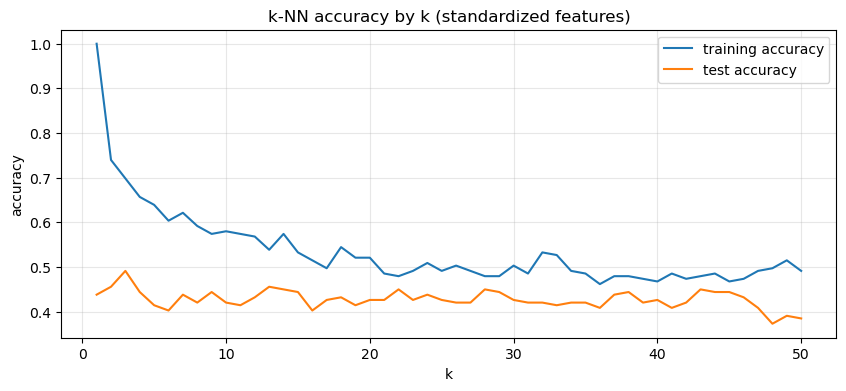

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(acc.index, acc['train'], label='training accuracy')
plt.plot(acc.index, acc['test'], label='test accuracy')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('k-NN accuracy by k (standardized features)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
k_best = int(acc['test'].idxmax())
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_best)).fit(X_train, y_train)
y_pred = knn.predict(X_test)

p = acc.loc[k_best, 'test']
print('standard error of test accuracy:', round((p * (1 - p) / len(y_test)) ** 0.5, 3))

standard error of test accuracy: 0.038


I standardized the features with `StandardScaler` inside a pipeline, so the scaler is fit on the training set only, then fit a $k$-NN classifier for every $k$ from 1 to 50 and compared training and test accuracy. At $k=1$ training accuracy is 100% but test accuracy is 43.8%, which is overfitting. Test accuracy peaks at $k=3$ with 49.1% (83 of 169), and for $k$ from 4 to 50 it stays between 37.3% and 45.6% as predictions average over more neighbours from other classes. I chose $k=3$ since it has the highest test accuracy. Standardizing raised the best test accuracy from 43.2% in Phase 1 to 49.1%, with the same $k$.

The peak is not a large one. $k=3$ is 6 test cases (3.55 points) ahead of $k=2$ and $k=13$, which both reach 45.6%, and the standard error of a 49.1% accuracy on 169 test cases is about 3.8 points, so the peak is within the noise of a single test set. Since $k$ was also picked using the test set, the 49.1% is probably a little optimistic for new data.

### Q2.4 - Confusion table for the optimal model

In [24]:
print(pd.crosstab(y_test, y_pred, rownames=['actual'], colnames=['predicted']))
print()
print('accuracy:', round(accuracy_score(y_test, y_pred), 3), f'({(y_test == y_pred).sum()} of {len(y_test)})')
print()
print(classification_report(y_test, y_pred, digits=3))

predicted   1   2   3  4  5
actual                     
1          27   0   4  2  3
2           0  30   1  3  1
3          12   3  11  1  6
4          10   2   8  9  4
5           9   1  13  3  6

accuracy: 0.491 (83 of 169)

              precision    recall  f1-score   support

           1      0.466     0.750     0.574        36
           2      0.833     0.857     0.845        35
           3      0.297     0.333     0.314        33
           4      0.500     0.273     0.353        33
           5      0.300     0.188     0.231        32

    accuracy                          0.491       169
   macro avg      0.479     0.480     0.464       169
weighted avg      0.484     0.491     0.471       169



In [25]:
# With 5 classes and k = 3, the three neighbours can all disagree (a 1-1-1 tie).
# scikit-learn breaks those ties by picking the lowest class label.
votes = knn.predict_proba(X_test).max(axis=1)
tie = votes < 0.5
actual_mine = (y_test != 1).values

print('unanimous (3-0):', (votes == 1).sum(), ' majority (2-1):', ((votes > 0.5) & (votes < 1)).sum(),
      ' three-way ties:', tie.sum())
print('"no mine" predictions:', (y_pred == 1).sum(), ' of which ties:', ((y_pred == 1) & tie).sum())
print('real mines called "no mine":', ((y_pred == 1) & actual_mine).sum(),
      ' of which ties:', ((y_pred == 1) & actual_mine & tie).sum())

unanimous (3-0): 31  majority (2-1): 79  three-way ties: 59
"no mine" predictions: 58  of which ties: 35
real mines called "no mine": 31  of which ties: 23


The model is correct on 83 of 169 test cases, an accuracy of 49.1%. That is about 2.3 times the 21% baseline, but performance is very uneven across classes.

Anti-tank mines (class 2) are the clear strength, with 30 of 35 identified (85.7% recall), 83.3% precision, and none called "no mine." "No mine" (class 1) has 27 of 36 correct. The three anti-personnel types are much weaker, with recall of 33.3% for class 3, 27.3% for class 4, and 18.8% for class 5. Most of their errors go to each other or to "no mine," which is where the voltage distributions overlapped in the EDA.

The "no mine" results need a qualification. With five classes and $k=3$, the three neighbours often all disagree, and 59 of the 169 predictions are 1–1–1 ties. scikit-learn breaks ties by picking the lowest class label, so in a three-way tie, whenever one of the three neighbours is class 1, the prediction becomes "no mine." That accounts for 35 of the 58 "no mine" predictions. So part of the class 1 recall comes from the label order rather than from the data, and the model is less confident about empty ground than the table makes it look. The model predicts "no mine" 58 times and only 27 of those are actually empty, so 31 real mines are labelled as no mine, and 23 of those 31 come from ties.

### Q2.5 - How to use this model in practice

In [26]:
# Collapse to the decision that matters: mine vs. no mine (class 1)
pred_mine = y_pred != 1
print(pd.crosstab(actual_mine, pred_mine, rownames=['actual mine'], colnames=['predicted mine']))
print()

# Stricter rules for treating a spot as low-risk, using the vote share for "no mine"
p_none = knn.predict_proba(X_test)[:, list(knn.classes_).index(1)]
for share, label in [(2/3, 'at least 2 of 3 neighbours'), (1.0, 'all 3 neighbours')]:
    low_risk = p_none >= share - 1e-9
    print(f'low-risk if {label} say no mine: {low_risk.sum()} spots, '
          f'{(low_risk & ~actual_mine).sum()} truly empty, {(low_risk & actual_mine).sum()} real mines')

predicted mine  False  True 
actual mine                 
False              27      9
True               31    102

low-risk if at least 2 of 3 neighbours say no mine: 23 spots, 15 truly empty, 8 real mines
low-risk if all 3 neighbours say no mine: 4 spots, 4 truly empty, 0 real mines


Collapsing the table to mine versus no mine, the model misses 31 of 133 real mines, and when it says "no mine" it is wrong 53.4% of the time (31 of 58). A false alarm costs time, but a missed mine can kill someone, so this model should not be used to declare ground safe. I would treat every "no mine" prediction as not yet cleared and keep the normal clearance process everywhere.

Where the model is useful is triage. Anti-tank predictions are reliable (85.7% recall and 83.3% precision, with no anti-tank mines called empty), so those spots can be flagged for anti-tank procedures right away. The model cannot reliably tell the three anti-personnel types apart, so if deminers handle them with similar precautions, it would make more sense to report a single "anti-personnel" prediction. That would not fix the safety problem, though, since all 31 missed mines are anti-personnel (12, 10, and 9 from classes 3, 4, and 5).

I would also use the predicted vote shares instead of only the label. Most "no mine" calls are tie-breaks backed by one neighbour out of three, so a single "no mine" label is weak evidence. Treating a spot as low-risk only when two of three neighbours agree flags 23 spots, but 8 of them are real mines. Requiring all three to agree flags only 4 spots, all truly empty, so the model is almost never confident enough to clear ground, and its realistic role is ranking which spots look most dangerous so they get checked first. Before field use it would also need testing on real minefield data, since 338 controlled readings do not include things like metal debris or mixed soils.

### *Reflection on AI assistance
In your own words without generative AI.

The most useful thing the AI found was that I had treated the features being on the same 0–1 scale as meaning they contributed equally to the distance calculation. Their spreads were actually quite different, and standardizing them raised test accuracy from 43.2% to 49.1% while reducing the number of real mines predicted as “no mine” from 40 to 31. It also improved parts of Question 1. In particular, it caught that my confusion-table explanation depended on specifying that rows were actual labels and columns were predicted labels, and it gave a concrete example for why probability distributions can be more informative than a single class label: 59 of 169 predictions in the final model were three-way ties. 

The AI was less useful when its recommendations went beyond what the assignment needed. For example, it suggested comparing alternative tie-breaking rules and collapsing mine classes. Those calculations were informative for checking the model, but I left most of them out of the final solution because they introduced additional modeling decisions without directly answering the questions. Distance weighting also removed the ties, but reduced accuracy, so I kept uniform voting and reported the tie issue as a limitation instead. 

I independently recomputed every numerical claim before accepting it, and all twelve recommendations reproduced correctly. 

My main remaining concern is that the selected model is still only 49.1% accurate and misses 31 real mines. Because many predictions also depend on tie-breaking, I would treat the model as a way to prioritize inspection rather than evidence that an area is safe.